# Complex Numbers — Lecture 6
## Practice Session: Polar Form with a Trap · Real Part of $e^{e^{i\theta}}$ · A Modulus Condition · Equilateral Triangle Identity

**Source:** [Complex Numbers 06 | Practice of Complex Numbers | Class 11 | JEE](https://youtu.be/8VNuTnLEAqE), Physics Wallah (Class 11), about 35 min

**Prerequisite:** Lectures 1–5, especially polar/Euler form (L5), $z\bar z = |z|^2$ (L2), arguments (L4), and the triangle inequality (L3).

### What this lecture covers
Four questions that use everything so far. *"Solving questions is the real test."*

| # | Question | Main tool |
|---|---|---|
| 1 | $z = 1 + \cos\frac{6\pi}{5} + i\sin\frac{6\pi}{5}$: find $\lvert z\rvert$ and $\operatorname{amp} z$ | half-angle formulas, polar form, **the sign of $r$** |
| 2 | Real part of $e^{e^{i\theta}}$ | Euler's formula, twice |
| 3 | If $\left\lvert\dfrac{z}{\lvert z\rvert} - \bar z\right\rvert = 1 + \lvert z\rvert$, then $z$ is …? | exponential form, modulus |
| 4 | $z_1, z_2, z_3$ form an equilateral triangle. Prove $\dfrac{1}{z_1 - z_2} + \dfrac{1}{z_2 - z_3} + \dfrac{1}{z_3 - z_1} = 0$ | $\lvert w\rvert^2 = w\bar w$ |

> The questions were shown on screen. The formulas here are reconstructed from the lecturer's spoken solution, and each one is checked numerically against his final answer.

Before each solution, the lecturer asks you to pause and try the question yourself first.

Sections marked *(extra)* go beyond what was said in the lecture.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# Same look as Lectures 1–5
BLUE, ORANGE, AQUA, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "axes.edgecolor": INK2, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
    "animation.embed_limit": 30,
})
rng = np.random.default_rng(6)

def argand(ax, lim=2.5, ticks=1):
    # Draw the complex plane: real axis horizontal, imaginary axis vertical
    ax.axhline(0, color=INK2, lw=1); ax.axvline(0, color=INK2, lw=1)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
    t = np.arange(ticks, lim, ticks); t = np.r_[-t[::-1], 0, t]
    ax.set_xticks(t)
    ax.set_yticks(t, ["0" if v == 0 else "i" if v == 1 else "−i" if v == -1 else f"{v:g}i".replace("-", "−") for v in t])
    ax.set_xlabel("Re"); ax.set_ylabel("Im")

def arrow(ax, z0, z1, color, lw=2, ls="-"):
    z0, z1 = complex(z0), complex(z1)
    ax.annotate("", (z1.real, z1.imag), (z0.real, z0.imag),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, ls=ls, mutation_scale=14, shrinkA=0, shrinkB=0))

def angle_arc(ax, theta, r=0.5, color=ORANGE, lw=2, start=0.0, center=0j):
    # Arc from `start` to `theta` (around `center`) with an arrowhead showing the direction
    t = np.linspace(start, theta, 80); c = complex(center)
    ax.plot(c.real + r*np.cos(t), c.imag + r*np.sin(t), color=color, lw=lw)
    ax.annotate("", (c.real + r*np.cos(t[-1]), c.imag + r*np.sin(t[-1])), (c.real + r*np.cos(t[-6]), c.imag + r*np.sin(t[-6])),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, mutation_scale=12))

def pi_str(x):
    # Pretty-print a multiple of π/12 like "5π/6" or "−π/4"
    from fractions import Fraction
    f = Fraction(x/np.pi).limit_denominator(12)
    if f == 0: return "0"
    s = "−" if f < 0 else ""; f = abs(f)
    num = "" if f.numerator == 1 else str(f.numerator)
    return f"{s}{num}π" + ("" if f.denominator == 1 else f"/{f.denominator}")
print("ready")

ready


---
## Q1. Modulus and Amplitude of $z = 1 + \cos\frac{6\pi}{5} + i\sin\frac{6\pi}{5}$

**Plan:** reshape $z$ into the standard polar form $r(\cos\theta + i\sin\theta)$ with **$r > 0$**, then read off $|z| = r$ and $\operatorname{amp} z = \theta$. A quick note: $|z|$ can never be negative, so any option with a negative modulus can be crossed out straight away.

**Step 1: half-angle formulas** (trigonometry), with $\theta = \frac{6\pi}{5}$, so $\frac{\theta}{2} = \frac{3\pi}{5}$:
$$1 + \cos\theta = 2\cos^2\frac{\theta}{2}, \qquad \sin\theta = 2\sin\frac{\theta}{2}\cos\frac{\theta}{2}$$
$$z = 2\cos^2\frac{3\pi}{5} + i\cdot2\sin\frac{3\pi}{5}\cos\frac{3\pi}{5}$$
Take $2\cos\frac{3\pi}{5}$ common:
$$z = 2\cos\frac{3\pi}{5}\left(\cos\frac{3\pi}{5} + i\sin\frac{3\pi}{5}\right)$$

**Step 2: the trap.** This *looks* like $r(\cos\theta + i\sin\theta)$ with $r = 2\cos\frac{3\pi}{5}$. But $\frac{3\pi}{5} = 108^\circ$ is in the second quadrant, where cosine is **negative**. So $2\cos\frac{3\pi}{5} < 0$, and calling it $r$ would be *"a big sin"*, because a modulus is never negative.

**Step 3: make the front factor positive.** Write $\cos\frac{3\pi}{5} = -\cos\frac{2\pi}{5}$, so the factor is $-2\cos\frac{2\pi}{5}$. Push the minus sign into the bracket:
$$z = 2\cos\frac{2\pi}{5}\left(-\cos\frac{3\pi}{5} - i\sin\frac{3\pi}{5}\right)$$
Use $\cos(x - \pi) = -\cos x$ and $\sin(x - \pi) = -\sin x$:
$$z = 2\cos\frac{2\pi}{5}\left[\cos\left(\frac{3\pi}{5} - \pi\right) + i\sin\left(\frac{3\pi}{5} - \pi\right)\right] = 2\cos\frac{2\pi}{5}\left[\cos\left(-\frac{2\pi}{5}\right) + i\sin\left(-\frac{2\pi}{5}\right)\right]$$
Now the front is positive ($\frac{2\pi}{5} = 72^\circ$) and the angle is in $(-\pi, \pi]$. This is the genuine standard form:
$$\boxed{|z| = 2\cos\frac{2\pi}{5}, \qquad \operatorname{amp} z = -\frac{2\pi}{5}}$$

*Why subtract $\pi$ rather than add it?* Adding $\pi$ gives $\frac{8\pi}{5}$, the same direction but outside the principal range. Subtracting keeps it in $(-\pi, \pi]$.

In [2]:
z = 1 + np.cos(6*np.pi/5) + 1j*np.sin(6*np.pi/5)
print(f"z = {z:.5f}")
print(f"|z|      = {abs(z):.6f}    2cos(2π/5) = {2*np.cos(2*np.pi/5):.6f}")
print(f"amp z    = {pi_str(np.angle(z))}")
print(f"2cos(3π/5) = {2*np.cos(3*np.pi/5):.6f}  ← negative, so it can't be the modulus")

z = 0.19098-0.58779j
|z|      = 0.618034    2cos(2π/5) = 0.618034
amp z    = −2π/5
2cos(3π/5) = -0.618034  ← negative, so it can't be the modulus


### Picture *(extra)*: what a "negative $r$" really does
Left: $2\cos\frac{3\pi}{5}\,(\cos\frac{3\pi}{5} + i\sin\frac{3\pi}{5})$ means "go $|r|$ units in the direction $\frac{3\pi}{5}$, but **backwards**". A negative $r$ flips the arrow by $\pi$. The true point is at angle $\frac{3\pi}{5} - \pi = -\frac{2\pi}{5}$.

Right: the geometric reason behind the half-angle step. $z = 1 + e^{i\theta}$ is the **diagonal of a rhombus** with sides $1$ and $e^{i\theta}$. A rhombus diagonal **bisects** the angle between its sides, which is where the half-angle comes from. Here $e^{i\cdot6\pi/5}$ has principal angle $-\frac{4\pi}{5}$, so the diagonal sits at half of that, $-\frac{2\pi}{5}$, with length $2\cos\frac{2\pi}{5}$.

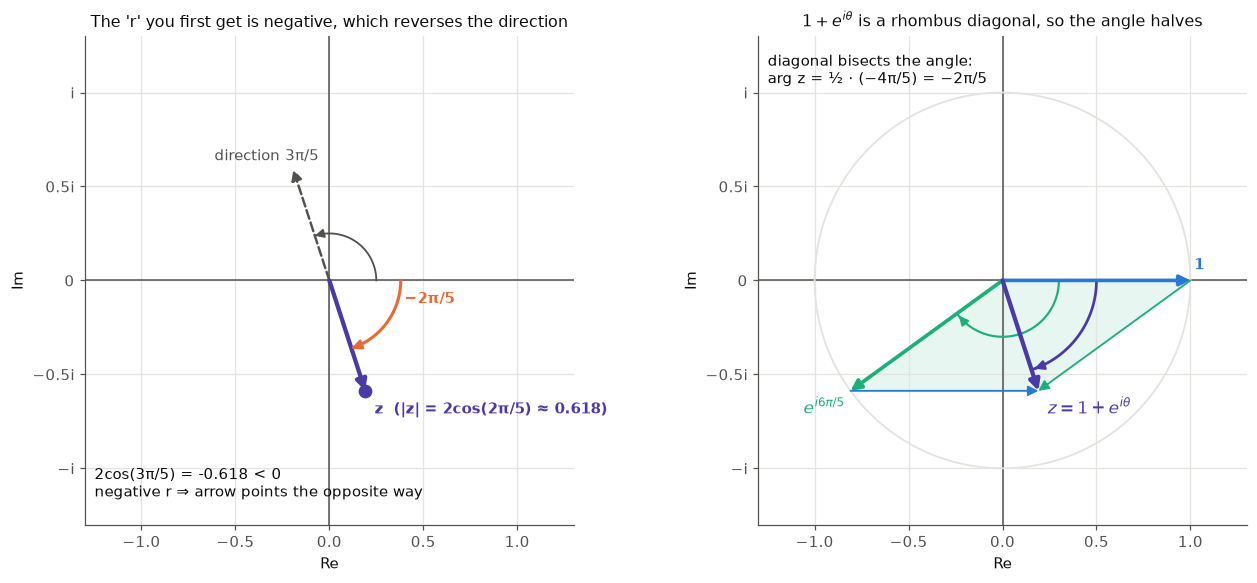

In [3]:
th = 6*np.pi/5; z = 1 + np.exp(1j*th)
fig, axes = plt.subplots(1, 2, figsize=(12, 5.4))
ax = axes[0]; argand(ax, lim=1.3, ticks=0.5)
u = np.exp(1j*3*np.pi/5); fake_r = 2*np.cos(3*np.pi/5)
arrow(ax, 0, 0.62*u, INK2, 1.6, ls="--"); ax.text((0.62*u).real - 0.42, (0.62*u).imag + 0.05, "direction 3π/5", color=INK2, fontsize=9.5)
angle_arc(ax, 3*np.pi/5, r=0.25, color=INK2, lw=1.2)
arrow(ax, 0, z, VIOLET, 2.8); ax.plot(z.real, z.imag, "o", color=VIOLET, ms=8)
angle_arc(ax, np.angle(z), r=0.38, color=ORANGE)
ax.text(z.real + 0.05, z.imag - 0.12, f"z  (|z| = 2cos(2π/5) ≈ {abs(z):.3f})", color=VIOLET, fontsize=9.5, weight="bold")
ax.text(0.4, -0.12, "−2π/5", color=ORANGE, weight="bold")
ax.text(-1.25, -1.15, f"2cos(3π/5) = {fake_r:.3f} < 0\nnegative r ⇒ arrow points the opposite way", fontsize=9.5, color=INK)
ax.set_title("The 'r' you first get is negative, which reverses the direction", fontsize=10.5)

ax = axes[1]; argand(ax, lim=1.3, ticks=0.5)
w = np.exp(1j*th)
c = np.linspace(0, 2*np.pi, 200); ax.plot(np.cos(c), np.sin(c), color=GRID, lw=1.2)
ax.fill([0, 1, z.real, w.real], [0, 0, z.imag, w.imag], color=AQUA, alpha=0.1)
arrow(ax, 0, 1, BLUE, 2.4); arrow(ax, 0, w, AQUA, 2.4); arrow(ax, 1, z, AQUA, 1.2); arrow(ax, w, z, BLUE, 1.2)
arrow(ax, 0, z, VIOLET, 2.8)
angle_arc(ax, np.angle(w), r=0.3, color=AQUA, lw=1.4); angle_arc(ax, np.angle(z), r=0.5, color=VIOLET, lw=1.8)
ax.text(1.02, 0.06, "1", color=BLUE, weight="bold"); ax.text(w.real - 0.25, w.imag - 0.12, r"$e^{i6\pi/5}$", color=AQUA, fontsize=11)
ax.text(z.real + 0.05, z.imag - 0.12, r"$z = 1 + e^{i\theta}$", color=VIOLET, fontsize=11)
ax.text(-1.25, 1.05, "diagonal bisects the angle:\narg z = ½ · (−4π/5) = −2π/5", fontsize=9.5)
ax.set_title(r"$1 + e^{i\theta}$ is a rhombus diagonal, so the angle halves", fontsize=10.5)
plt.tight_layout(); plt.show()

### Animation *(extra)*: $1 + e^{i\theta}$ for every $\theta$
As $\theta$ runs from $0$ to $2\pi$, $e^{i\theta}$ circles the origin. So $z = 1 + e^{i\theta}$ circles the point $1$, passing through the origin at $\theta = \pi$. The right panel compares $\operatorname{Arg} z$ with $\frac{\theta}{2}$:
- for $\theta < \pi$: $\operatorname{Arg} z = \frac{\theta}{2}$ and $|z| = 2\cos\frac{\theta}{2}$, a positive "r";
- for $\theta > \pi$, the situation in Q1: $\cos\frac{\theta}{2} < 0$, so $\operatorname{Arg} z = \frac{\theta}{2} - \pi$ and $|z| = -2\cos\frac{\theta}{2}$.

The jump at $\theta = \pi$ is exactly the "negative $r$" trap.

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.9), dpi=72, gridspec_kw=dict(width_ratios=[1, 1.3]))
ax = axes[0]; argand(ax, lim=2.3)
c = np.linspace(0, 2*np.pi, 300); ax.plot(1 + np.cos(c), np.sin(c), color=GRID, lw=1.5)
s1, = ax.plot([], [], color=BLUE, lw=2); s2, = ax.plot([], [], color=AQUA, lw=2)
p1, = ax.plot([], [], color=AQUA, lw=1, ls="--"); p2, = ax.plot([], [], color=BLUE, lw=1, ls="--")
dg, = ax.plot([], [], color=VIOLET, lw=2.8); dot, = ax.plot([], [], "o", color=VIOLET, ms=8)
info = ax.text(-2.2, -2.15, "", fontsize=10, family="monospace")
ax.set_title(r"$z = 1 + e^{i\theta}$: the rhombus and its diagonal", fontsize=10.5)
ax2 = axes[1]
T = np.linspace(0.001, 2*np.pi - 0.001, 400); A = np.angle(1 + np.exp(1j*T))
ax2.plot(T, T/2, color=INK2, lw=1, ls="--", label="θ/2")
ax2.plot(T[T < np.pi], A[T < np.pi], color=VIOLET, lw=1, alpha=0.3); ax2.plot(T[T > np.pi], A[T > np.pi], color=VIOLET, lw=1, alpha=0.3)
tr, = ax2.plot([], [], color=VIOLET, lw=2.6, label=r"Arg$(1 + e^{i\theta})$"); td, = ax2.plot([], [], "o", color=VIOLET, ms=7)
ax2.axvline(6*np.pi/5, color=ORANGE, lw=1, ls=":"); ax2.text(6*np.pi/5 + 0.05, 1.9, "Q1: θ = 6π/5", color=ORANGE, fontsize=9)
ax2.set_xticks(np.arange(5)*np.pi/2, ["0", "π/2", "π", "3π/2", "2π"]); ax2.set_xlim(0, 2*np.pi)
ax2.set_yticks(np.arange(-2, 5)*np.pi/4, ["−π/2", "−π/4", "0", "π/4", "π/2", "3π/4", "π"]); ax2.set_ylim(-1.8, 3.3)
ax2.set_xlabel("θ"); ax2.legend(frameon=False, fontsize=9, loc="upper left")
ax2.set_title("Arg z = θ/2 until θ = π, then θ/2 − π", fontsize=10.5)
N = 44
def update(f):
    t = 0.02 + (2*np.pi - 0.04)*f/(N - 1); w = np.exp(1j*t); z = 1 + w
    s1.set_data([0, 1], [0, 0]); s2.set_data([0, w.real], [0, w.imag])
    p1.set_data([1, z.real], [0, z.imag]); p2.set_data([w.real, z.real], [w.imag, z.imag])
    dg.set_data([0, z.real], [0, z.imag]); dot.set_data([z.real], [z.imag])
    k = np.searchsorted(T, t); a = A[:k + 1].copy(); a[1:][np.abs(np.diff(a)) > 1] = np.nan
    tr.set_data(T[:k + 1], a); td.set_data([t], [np.angle(z)])
    info.set_text(f"θ={t:4.2f}  |z|={abs(z):.2f}  2cos(θ/2)={2*np.cos(t/2):+.2f}")
    return s1, s2, p1, p2, dg, dot, info, tr, td
anim = animation.FuncAnimation(fig, update, frames=N, interval=110, blit=True)
plt.close(fig)
HTML(anim.to_jshtml(default_mode="loop"))

---
## Q2. Find the Real Part of $e^{e^{i\theta}}$

**Idea:** to read off a real part, the number must be in **algebraic form** $x + iy$, or polar form. Here it is in a stacked exponential form, so convert it.

**Step 1.** The inner $e^{i\theta}$ is Euler's form: $e^{i\theta} = \cos\theta + i\sin\theta$, so
$$e^{e^{i\theta}} = e^{\cos\theta + i\sin\theta}$$
**Step 2.** Powers that add can be split into a product: $e^{a + b} = e^a\cdot e^b$:
$$= e^{\cos\theta}\cdot e^{i\sin\theta}$$
**Step 3.** Apply Euler again to $e^{i\sin\theta}$, treating $\sin\theta$ as the angle (call it $x$, so $e^{ix} = \cos x + i\sin x$):
$$= e^{\cos\theta}\left[\cos(\sin\theta) + i\sin(\sin\theta)\right] = e^{\cos\theta}\cos(\sin\theta) + i\,e^{\cos\theta}\sin(\sin\theta)$$
$$\boxed{\operatorname{Re}\left(e^{e^{i\theta}}\right) = e^{\cos\theta}\cos(\sin\theta)}$$
And the imaginary part is $e^{\cos\theta}\sin(\sin\theta)$.

> The lecturer's point: the three forms are three faces of the same number. Pick the one that suits the question. For a real part, you need $x + iy$.

In [5]:
th = rng.uniform(-10, 10, 100_000)
w = np.exp(np.exp(1j*th))
print(f"Re e^(e^(iθ)) = e^(cos θ)·cos(sin θ):  holds on {np.isclose(w.real, np.exp(np.cos(th))*np.cos(np.sin(th))).mean()*100:.2f}% of 100,000 θ")
print(f"Im e^(e^(iθ)) = e^(cos θ)·sin(sin θ):  holds on {np.isclose(w.imag, np.exp(np.cos(th))*np.sin(np.sin(th))).mean()*100:.2f}%")

Re e^(e^(iθ)) = e^(cos θ)·cos(sin θ):  holds on 100.00% of 100,000 θ
Im e^(e^(iθ)) = e^(cos θ)·sin(sin θ):  holds on 100.00%


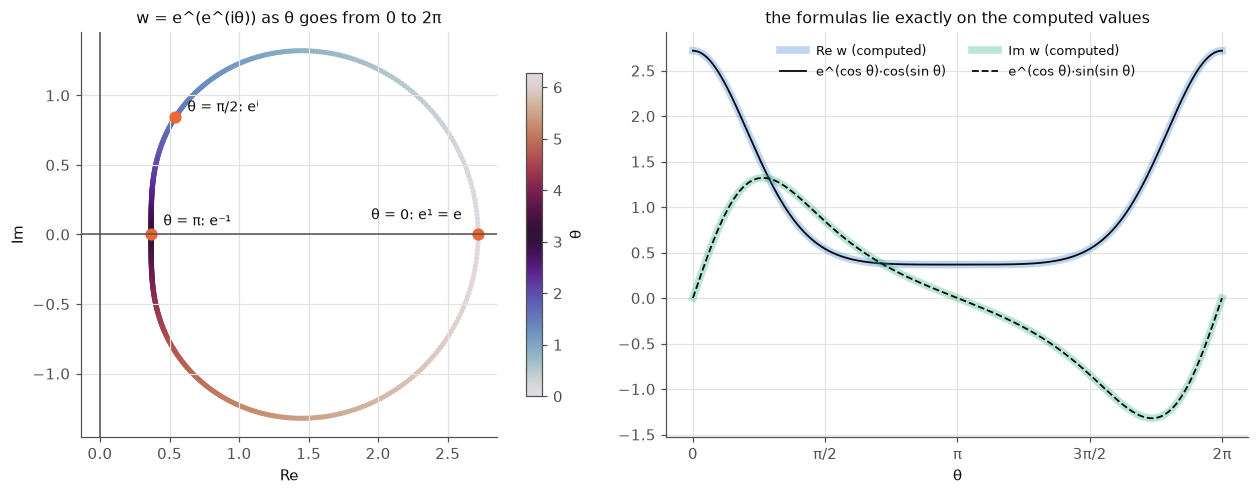

In [6]:
# Picture (extra): as θ goes round once, w = e^(e^(iθ)) traces a closed loop; its real part follows the formula
T = np.linspace(0, 2*np.pi, 600); W = np.exp(np.exp(1j*T))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
ax = axes[0]
sc = ax.scatter(W.real, W.imag, c=T, cmap="twilight", s=6)
for t, lab, off in [(0, "θ = 0: e¹ = e", (-70, 10)), (np.pi/2, "θ = π/2: eⁱ", (8, 4)), (np.pi, "θ = π: e⁻¹", (8, 6))]:
    p = np.exp(np.exp(1j*t)); ax.plot(p.real, p.imag, "o", color=ORANGE, ms=7)
    ax.annotate(lab, (p.real, p.imag), xytext=off, textcoords="offset points", fontsize=9)
ax.axhline(0, color=INK2, lw=1); ax.axvline(0, color=INK2, lw=1); ax.set_aspect("equal")
ax.set_xlabel("Re"); ax.set_ylabel("Im"); fig.colorbar(sc, ax=ax, shrink=0.8, label="θ")
ax.set_title("w = e^(e^(iθ)) as θ goes from 0 to 2π", fontsize=10.5)
ax = axes[1]
ax.plot(T, W.real, color=BLUE, lw=5, alpha=0.3, label="Re w (computed)")
ax.plot(T, np.exp(np.cos(T))*np.cos(np.sin(T)), color=INK, lw=1.2, label="e^(cos θ)·cos(sin θ)")
ax.plot(T, W.imag, color=AQUA, lw=5, alpha=0.3, label="Im w (computed)")
ax.plot(T, np.exp(np.cos(T))*np.sin(np.sin(T)), color=INK, lw=1.2, ls="--", label="e^(cos θ)·sin(sin θ)")
ax.set_xticks(np.arange(5)*np.pi/2, ["0", "π/2", "π", "3π/2", "2π"]); ax.set_xlabel("θ")
ax.legend(frameon=False, fontsize=8.5, loc="upper center", ncol=2)
ax.set_title("the formulas lie exactly on the computed values", fontsize=10.5)
plt.tight_layout(); plt.show()

---
## Q3. If $\left|\dfrac{z}{|z|} - \bar z\right| = 1 + |z|$, then $z$ is …

(a) purely real  (b) purely imaginary  (c) neither  (d) both

**Step 1: exponential form.** Just as any $z$ can be written $x + iy$, it can be written $z = re^{i\theta}$. Then
$$|z| = r, \qquad \bar z = re^{-i\theta}$$
(the conjugate keeps the modulus and flips the sign of the argument, from Lectures 2 and 4).

**Step 2: substitute.** $\frac{z}{|z|} = \frac{re^{i\theta}}{r} = e^{i\theta}$, since the $r$'s cancel. The condition becomes
$$\left|e^{i\theta} - re^{-i\theta}\right| = 1 + r$$

**Step 3: expand with Euler.**
$$e^{i\theta} - re^{-i\theta} = (\cos\theta + i\sin\theta) - r(\cos\theta - i\sin\theta) = \underbrace{\cos\theta\,(1 - r)}_{\text{real}} + i\,\underbrace{\sin\theta\,(1 + r)}_{\text{imaginary}}$$

**Step 4: modulus, then square both sides.**
$$\cos^2\theta\,(1 - r)^2 + \sin^2\theta\,(1 + r)^2 = (1 + r)^2$$
Move $(1 + r)^2$ to the left and pair it with the $\sin^2\theta$ term. Since $\sin^2\theta - 1 = -\cos^2\theta$:
$$\cos^2\theta\,(1 - r)^2 - \cos^2\theta\,(1 + r)^2 = 0 \;\Longrightarrow\; \cos^2\theta\left[(1 - r)^2 - (1 + r)^2\right] = 0 \;\Longrightarrow\; \cos^2\theta\,(-4r) = 0$$

**Step 5: which factor is zero?**
- $r = 0$ would mean $z = 0$. But $|z|$ is in a **denominator**, and a zero denominator leaves the expression undefined ("silence"). So $r \ne 0$.
- Therefore $\cos\theta = 0$, so $\theta = \pm\frac{\pi}{2}$.

A complex number with argument $\pm\frac{\pi}{2}$ lies on the **imaginary axis**:
$$\boxed{z \text{ is purely imaginary (and nonzero)}}$$

In [7]:
f = lambda z: abs(z/abs(z) - np.conj(z)) - (1 + abs(z))
print("on the imaginary axis (should be 0):", [round(float(f(complex(0, y))), 12) for y in [3, 0.5, -2, -7]])
print("off the axis (should be ≠ 0)       :", [round(float(f(z)), 4) for z in [1 + 1j, 2, -3 + 0.1j, 0.5 + 5j]])

on the imaginary axis (should be 0): [0.0, 0.0, 0.0, 0.0]
off the axis (should be ≠ 0)       : [-0.6822, -2.0, -1.9967, -0.0165]


### Another way to see it *(extra)*: equality in the triangle inequality
By the triangle inequality (Lecture 3),
$$\left|\frac{z}{|z|} + (-\bar z)\right| \le \left|\frac{z}{|z|}\right| + |-\bar z| = 1 + |z|$$
The question says **equality** holds. That happens **only** when the two pieces point in the **same direction** (the triangle collapses flat). $\frac{z}{|z|}$ points at angle $\theta$, and $-\bar z$ points at angle $\pi - \theta$. These are equal only when $\theta = \pi - \theta$, up to a full turn, which gives $\theta = \pm\frac{\pi}{2}$. Same answer, no algebra.

The map shows the "gap" $(1 + |z|) - \left|\frac{z}{|z|} - \bar z\right|$ at every point. It is zero **only** along the imaginary axis.

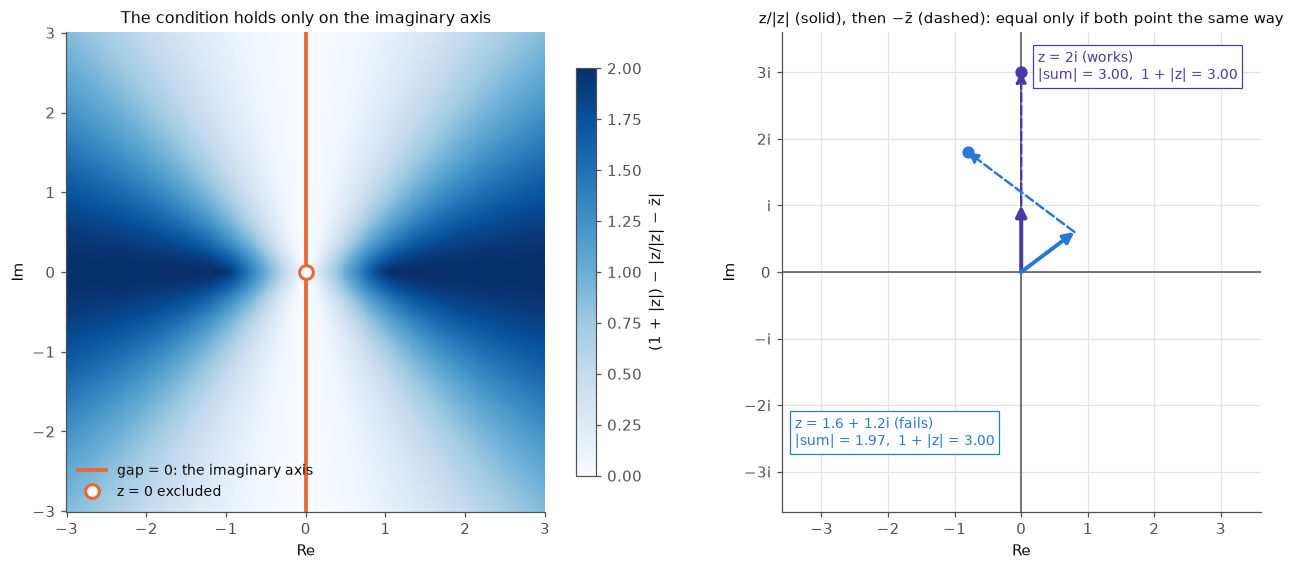

In [8]:
X, Y = np.meshgrid(np.linspace(-3, 3, 501), np.linspace(-3, 3, 501)); Z = X + 1j*Y
with np.errstate(invalid="ignore", divide="ignore"):
    G = (1 + np.abs(Z)) - np.abs(Z/np.abs(Z) - np.conj(Z))
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), gridspec_kw=dict(width_ratios=[1.15, 1]))
ax = axes[0]; ax.grid(False)
im = ax.pcolormesh(X, Y, G, cmap="Blues", shading="auto")
ax.plot([0, 0], [-3, 3], color=ORANGE, lw=2.5, label="gap = 0: the imaginary axis")
ax.plot(0, 0, "o", ms=9, mfc="white", mec=ORANGE, mew=2, label="z = 0 excluded")
ax.set_aspect("equal"); ax.set_xlabel("Re"); ax.set_ylabel("Im"); ax.legend(frameon=False, loc="lower left", fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.85, label="(1 + |z|) − |z/|z| − z̄|")
ax.set_title("The condition holds only on the imaginary axis", fontsize=10.5)

ax = axes[1]; argand(ax, lim=3.6)
for z, col, tag, pos in [(2j, VIOLET, "z = 2i (works)", (0.25, 2.9)), (1.6 + 1.2j, BLUE, "z = 1.6 + 1.2i (fails)", (-3.4, -2.6))]:
    u = z/abs(z); v = -np.conj(z)
    arrow(ax, 0, u, col, 2.6); arrow(ax, u, u + v, col, 1.6, ls="--")
    ax.plot((u + v).real, (u + v).imag, "o", color=col, ms=7)
    ax.text(*pos, f"{tag}\n|sum| = {abs(u + v):.2f},  1 + |z| = {1 + abs(z):.2f}", color=col, fontsize=9,
            bbox=dict(fc="white", ec=col, lw=0.8, pad=3))
ax.set_title("z/|z| (solid), then −z̄ (dashed): equal only if both point the same way", fontsize=9.5)
plt.tight_layout(); plt.show()

---
## Q4. Equilateral Triangle: Prove $\dfrac{1}{z_1 - z_2} + \dfrac{1}{z_2 - z_3} + \dfrac{1}{z_3 - z_1} = 0$

$z_1, z_2, z_3$ are the vertices $A, B, C$ of an **equilateral** triangle.

**Step 1: what does "equilateral" give us?** An equilateral triangle has equal sides (and equal angles, but the sides are what's useful here). The side lengths are distances between vertices, which are moduli of differences:
$$|z_1 - z_2| = |z_2 - z_3| = |z_3 - z_1| = k \qquad (k > 0)$$

**Step 2: square and use $|w|^2 = w\bar w$.**
$$(z_1 - z_2)\overline{(z_1 - z_2)} = k^2 \;\Longrightarrow\; \bar z_1 - \bar z_2 = \frac{k^2}{z_1 - z_2} \qquad (1)$$
The bar passes through subtraction (Lecture 2). The aim is to get $z_1 - z_2$ into a **denominator**, because that's what the target expression has. In the same way:
$$\bar z_2 - \bar z_3 = \frac{k^2}{z_2 - z_3} \quad (2), \qquad \bar z_3 - \bar z_1 = \frac{k^2}{z_3 - z_1} \quad (3)$$

**Step 3: add (1) + (2) + (3).** The left side telescopes to $0$:
$$(\bar z_1 - \bar z_2) + (\bar z_2 - \bar z_3) + (\bar z_3 - \bar z_1) = 0 = k^2\left[\frac{1}{z_1 - z_2} + \frac{1}{z_2 - z_3} + \frac{1}{z_3 - z_1}\right]$$
$k \ne 0$, since a triangle's side can't have zero length, so the bracket must vanish:
$$\boxed{\frac{1}{z_1 - z_2} + \frac{1}{z_2 - z_3} + \frac{1}{z_3 - z_1} = 0} \quad\blacksquare$$
*"Instead of 'Hence Proved' we draw a smile, because we prefer smiling."* 🙂

> **Logic recap:** "equilateral" gives three equal sides, which gives equal $|z_i - z_j|$. Squaring with $|w|^2 = w\bar w$ moves each $z_i - z_j$ into a denominator. Adding makes the left side cancel completely.

In [9]:
def equilateral(a, side, angle, ccw=True):
    # Vertices of an equilateral triangle starting at a, first side of given length and direction
    b = a + side*np.exp(1j*angle); c = a + (b - a)*np.exp(1j*np.pi/3*(1 if ccw else -1))
    return a, b, c
S = lambda a, b, c: 1/(a - b) + 1/(b - c) + 1/(c - a)
vals = [abs(S(*equilateral(complex(*rng.normal(size=2)*3), rng.uniform(0.5, 4), rng.uniform(0, 2*np.pi), rng.random() < 0.5)))
        for _ in range(100_000)]
print(f"equilateral: max |sum| over 100,000 random triangles = {max(vals):.2e}  (zero up to rounding)")
nonq = [abs(S(*(rng.normal(size=3) + 1j*rng.normal(size=3)))) for _ in range(5)]
print("random (not equilateral) triangles: |sum| =", np.round(nonq, 3))

equilateral: max |sum| over 100,000 random triangles = 4.58e-15  (zero up to rounding)
random (not equilateral) triangles: |sum| = [0.601 0.47  2.794 5.561 1.21 ]


### Animation *(extra)*: the three terms close into a triangle only when the triangle is equilateral
Draw the three numbers $\frac{1}{z_1 - z_2}$, $\frac{1}{z_2 - z_3}$, $\frac{1}{z_3 - z_1}$ **tip to tail** on the right. Their sum is zero exactly when the path **closes**.

On the left, vertex $C$ slides along a path that passes through the equilateral position. Watch the gap (orange) shrink to nothing at that moment and open again afterwards.

*(The converse also holds. If the sum is zero, the triangle is equilateral. It isn't needed here, but it's a classic result.)*

In [10]:
A, B = 0j, 2 + 0j; C_eq = A + (B - A)*np.exp(1j*np.pi/3)
N = 41; s = np.linspace(-1, 1, N)
path = C_eq + 0.9*s + 0.35j*s**2          # C moves left→right, through the equilateral spot at s = 0
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=72)
ax = axes[0]; ax.set_xlim(-1.2, 3.2); ax.set_ylim(-0.6, 2.6); ax.set_aspect("equal"); ax.set_xlabel("Re"); ax.set_ylabel("Im")
ax.plot(path.real, path.imag, color=GRID, lw=1.5, ls="--"); ax.plot(C_eq.real, C_eq.imag, "*", color=ORANGE, ms=13, zorder=6)
tri, = ax.plot([], [], color=VIOLET, lw=2.4); vC, = ax.plot([], [], "o", color=VIOLET, ms=9)
ax.plot([A.real, B.real], [A.imag, B.imag], "o", color=VIOLET, ms=9)
ax.text(-0.25, -0.3, "z₁ = A", color=VIOLET); ax.text(2.0, -0.3, "z₂ = B", color=VIOLET); tC = ax.text(0, 0, "z₃ = C", color=VIOLET)
sides = ax.text(-1.1, 2.35, "", fontsize=9.5, family="monospace")
ax.set_title("C slides through the equilateral position (★)", fontsize=10.5)
ax2 = axes[1]; argand(ax2, lim=0.85, ticks=0.25)
l1, = ax2.plot([], [], color=BLUE, lw=2.6); l2, = ax2.plot([], [], color=AQUA, lw=2.6); l3, = ax2.plot([], [], color=VIOLET, lw=2.6)
gap, = ax2.plot([], [], color=ORANGE, lw=3); end, = ax2.plot([], [], "o", color=ORANGE, ms=7)
ax2.plot([], [], color=BLUE, lw=2.6, label="1/(z₁−z₂)"); ax2.plot([], [], color=AQUA, lw=2.6, label="1/(z₂−z₃)")
ax2.plot([], [], color=VIOLET, lw=2.6, label="1/(z₃−z₁)"); ax2.plot([], [], color=ORANGE, lw=3, label="gap = |sum|")
ax2.legend(frameon=False, fontsize=8.5, loc="lower left")
gtxt = ax2.text(-0.8, 0.7, "", fontsize=10, family="monospace")
ax2.set_title("the three terms placed tip to tail", fontsize=10.5)
def update(f):
    C = path[f]
    tri.set_data([A.real, B.real, C.real, A.real], [A.imag, B.imag, C.imag, A.imag]); vC.set_data([C.real], [C.imag])
    tC.set_position((C.real + 0.08, C.imag + 0.1))
    sides.set_text(f"|AB|={abs(A-B):.2f} |BC|={abs(B-C):.2f} |CA|={abs(C-A):.2f}")
    t1, t2, t3 = 1/(A - B), 1/(B - C), 1/(C - A); p1, p2, p3 = t1, t1 + t2, t1 + t2 + t3
    l1.set_data([0, p1.real], [0, p1.imag]); l2.set_data([p1.real, p2.real], [p1.imag, p2.imag]); l3.set_data([p2.real, p3.real], [p2.imag, p3.imag])
    gap.set_data([p3.real, 0], [p3.imag, 0]); end.set_data([p3.real], [p3.imag])
    gtxt.set_text(f"|sum| = {abs(p3):.3f}" + ("   closed!" if abs(p3) < 0.02 else ""))
    return tri, vC, tC, sides, l1, l2, l3, gap, end, gtxt
anim = animation.FuncAnimation(fig, update, frames=N, interval=120, blit=True)
plt.close(fig)
HTML(anim.to_jshtml(default_mode="loop"))

---
## Summary: Techniques from This Session

| Question | Key move | Watch out for |
|---|---|---|
| Q1: $\lvert z\rvert$, $\operatorname{amp}$ of $1 + \cos\theta + i\sin\theta$ | half-angle formulas, then take the common factor to get the polar look | the front factor must be **positive** before you call it $r$. If not, absorb $-1$ via $\theta \to \theta - \pi$ |
| Q2: $\operatorname{Re}\,e^{e^{i\theta}}$ | Euler, then $e^{a+b} = e^ae^b$, then Euler again | a real part needs $x + iy$ form |
| Q3: $\left\lvert\frac{z}{\lvert z\rvert} - \bar z\right\rvert = 1 + \lvert z\rvert$ | $z = re^{i\theta}$, $\bar z = re^{-i\theta}$, take the modulus and square | $r \ne 0$ because $\lvert z\rvert$ is in a denominator |
| Q4: equilateral, so $\sum\frac{1}{z_i - z_j} = 0$ | equal sides, then $\lvert w\rvert^2 = w\bar w$, then add | aim for the target's shape: get $z_i - z_j$ into the denominator |

**The big lesson:** algebraic, polar and exponential are three faces of one number. Choose the face that makes the question easy.

> *"Complex numbers aren't difficult. Your thoughts just have to point in the right direction."*

---
## Practice *(extra)*
1. Find $|z|$ and $\operatorname{amp} z$ for $z = 1 - \cos\frac{8\pi}{5} + i\sin\frac{8\pi}{5}$. *(Hint: $1 - \cos\theta = 2\sin^2\frac{\theta}{2}$.)*
2. Find the imaginary part of $e^{2e^{i\theta}}$.
3. If $|z + 1| = |z - 1|$, what kind of number is $z$? *(Try it with $z = x + iy$, then explain it geometrically.)*
4. If $z_1, z_2, z_3$ form an equilateral triangle **and** $z_1 + z_2 + z_3 = 0$, show that $z_1^2 + z_2^2 + z_3^2 = 0$.

<details>
<summary>Answers (open after attempting)</summary>

1. $z = 2\sin^2\frac{4\pi}{5} + 2i\sin\frac{4\pi}{5}\cos\frac{4\pi}{5} = 2\sin\frac{4\pi}{5}\left(\sin\frac{4\pi}{5} + i\cos\frac{4\pi}{5}\right)$. $\sin\frac{4\pi}{5} > 0$, and $\sin\alpha + i\cos\alpha = \cos\left(\frac{\pi}{2} - \alpha\right) + i\sin\left(\frac{\pi}{2} - \alpha\right)$. So $|z| = 2\sin\frac{4\pi}{5} = 2\sin\frac{\pi}{5}$ and $\operatorname{amp} z = \frac{\pi}{2} - \frac{4\pi}{5} = -\frac{3\pi}{10}$.
2. $e^{2\cos\theta}\sin(2\sin\theta)$.
3. $(x + 1)^2 + y^2 = (x - 1)^2 + y^2$ gives $x = 0$, so $z$ is purely imaginary (or $0$). Geometrically, $z$ is equidistant from $-1$ and $1$, so it lies on their perpendicular bisector, the imaginary axis.
4. With the centroid at the origin, the vertices are $z_1, \omega z_1, \omega^2z_1$, where $\omega = e^{2\pi i/3}$. Then $\sum z_k^2 = z_1^2(1 + \omega^2 + \omega^4) = z_1^2(1 + \omega + \omega^2) = 0$. *(Cube roots of unity come in a later lecture.)*
</details>

In [11]:
# Checks for the practice set
z = 1 - np.cos(8*np.pi/5) + 1j*np.sin(8*np.pi/5)
print("1:", round(abs(z), 6), "=", round(2*np.sin(np.pi/5), 6), "  amp =", pi_str(np.angle(z)), "(−3π/10 =", round(-0.3*np.pi, 6), "vs", round(np.angle(z), 6), ")")
th = rng.uniform(-5, 5, 10_000); print("2:", np.allclose(np.exp(2*np.exp(1j*th)).imag, np.exp(2*np.cos(th))*np.sin(2*np.sin(th))))
on_axis = 1j*rng.normal(size=10_000)*3; off_axis = on_axis + rng.uniform(0.1, 3, 10_000)*rng.choice([-1, 1], 10_000)
print("3: |z+1| = |z−1| on the imaginary axis:", np.allclose(np.abs(on_axis + 1), np.abs(on_axis - 1)),
      "  off it:", np.isclose(np.abs(off_axis + 1), np.abs(off_axis - 1)).any())
w = np.exp(2j*np.pi/3); z1 = 1.7*np.exp(0.4j); v = np.array([z1, w*z1, w*w*z1])
print("4: sum =", np.round(v.sum(), 12), "  sum of squares =", np.round((v**2).sum(), 12), "  sides:", np.round(np.abs(v - np.roll(v, 1)), 6))

1: 1.175571 = 1.175571   amp = −3π/10 (−3π/10 = -0.942478 vs -0.942478 )
2: True
3: |z+1| = |z−1| on the imaginary axis: True   off it: False
4: sum = (-0+0j)   sum of squares = 0j   sides: [2.944486 2.944486 2.944486]
